# Survival regression

https://lifelines.readthedocs.io/en/latest/Survival%20Regression.html

In [31]:
from lifelines.datasets import load_rossi
import numpy as np
import matplotlib.pyplot as plt


rossi = load_rossi()

In [14]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

rossi = load_rossi()

cph = CoxPHFitter()
cph.fit(rossi, duration_col='week', event_col='arrest')

cph.print_summary()  # access the individual results using cph.summary

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -658.75
         time fit was run = 2025-10-15 19:50:00 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.38      0.68      0.19           -0.75           -0.00                0.47                1.00
age       -0.06      0.94      0.02           -0.10           -0.01                0.90                0.99
race       0.31      1.37      0.31           -0.29            0.92                0.75                2.50
wexp      -0.15      0.86      0.21           -0.57            0.27                0.57                1.30
mar       -0.43      0.65      0.38           -1.18            0.31                0.31                1.37
paro      -0.08      0.92      0.20           -0.47            0.30                0.63                1.35
prio       0.09      1.10      0.03            0.04            0.15                1.04                1.16

           cmp to     z      p  -log2(p)
covariate                               
fin          0.00 -1.98   0.05      4.40
age          0.00 -2.61   0.01      6.79
race         0.00  1.02   0.31      1.70
wexp         0.00 -0.71   0.48      1.06
mar          0.00 -1.14   0.26      1.97
paro         0.00 -0.43   0.66      0.59
prio         0.00  3.19 <0.005      9.48
---
Concordance = 0.64
Partial AIC = 1331.50
log-likelihood ratio test = 33.27 on 7 df
-log2(p) of ll-ratio test = 15.37

In [15]:
cph.fit(rossi, duration_col='week', event_col='arrest', formula="fin + wexp + age * prio")


<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>

In [16]:
cph.fit(rossi, duration_col='week', event_col='arrest', formula="fin + wexp + age * prio")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -659.39
         time fit was run = 2025-10-15 19:50:00 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.33      0.72      0.19           -0.70            0.04                0.49                1.05
wexp      -0.24      0.79      0.21           -0.65            0.17                0.52                1.19
age       -0.03      0.97      0.03           -0.09            0.03                0.92                1.03
prio       0.31      1.36      0.17           -0.03            0.64                0.97                1.90
age:prio  -0.01      0.99      0.01           -0.02            0.01                0.98                1.01

           cmp to     z    p  -log2(p)
covariate                             
fin          0.00 -1.73 0.08      3.57
wexp         0.00 -1.14 0.26      1.97
age          0.00 -0.93 0.35      1.51
prio         0.00  1.80 0.07      3.80
age:prio     0.00 -1.28 0.20      2.32
---
Concordance = 0.64
Partial AIC = 1328.77
log-likelihood ratio test = 31.99 on 5 df
-log2(p) of ll-ratio test = 17.35

In [17]:
X = rossi

cph.predict_survival_function(X)
cph.predict_median(X)
cph.predict_partial_hazard(X)

0      1.157686
1      3.768718
2      4.919517
3      0.699116
4      1.447786
         ...   
427    0.520233
428    1.385036
429    0.784224
430    0.812407
431    0.672850
Length: 432, dtype: float64

In [18]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

rossi = load_rossi()

cph = CoxPHFitter(penalizer=0.1, l1_ratio=1.0) # sparse solutions,
cph.fit(rossi, 'week', 'arrest')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
                penalizer = 0.1
                 l1 ratio = 1.0
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -675.38
         time fit was run = 2025-10-15 19:50:00 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
age       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
race       0.00      1.00      0.00           -0.00            0.00                1.00                1.00
wexp      -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
mar       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
paro      -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
prio       0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to     z    p  -log2(p)
covariate                             
fin          0.00 -0.00 1.00      0.00
age          0.00 -0.00 1.00      0.00
race         0.00  0.00 1.00      0.00
wexp         0.00 -0.00 1.00      0.00
mar          0.00 -0.00 1.00      0.00
paro         0.00 -0.00 1.00      0.00
prio         0.00  0.00 1.00      0.00
---
Concordance = 0.64
Partial AIC = 1364.76
log-likelihood ratio test = -0.00 on 7 df
-log2(p) of ll-ratio test = -0.00

In [19]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

rossi = load_rossi()

# variable `fin` is the treatment of interest so don't penalize it at all
penalty = np.array([0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

cph = CoxPHFitter(penalizer=penalty)
cph.fit(rossi, 'week', 'arrest')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
                penalizer = [0.  0.5 0.5 0.5 0.5 0.5 0.5]
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -667.42
         time fit was run = 2025-10-15 19:50:00 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.38      0.69      0.19           -0.75           -0.00                0.47                1.00
age       -0.02      0.98      0.01           -0.03            0.00                0.97                1.00
race       0.09      1.10      0.17           -0.23            0.42                0.79                1.53
wexp      -0.15      0.86      0.11           -0.37            0.07                0.69                1.07
mar       -0.17      0.84      0.17           -0.51            0.17                0.60                1.18
paro      -0.04      0.96      0.11           -0.26            0.19                0.77                1.20
prio       0.04      1.04      0.02            0.00            0.07                1.00                1.08

           cmp to     z    p  -log2(p)
covariate                             
fin          0.00 -1.97 0.05      4.37
age          0.00 -1.75 0.08      3.64
race         0.00  0.56 0.57      0.80
wexp         0.00 -1.34 0.18      2.47
mar          0.00 -0.98 0.33      1.61
paro         0.00 -0.32 0.75      0.42
prio         0.00  2.00 0.05      4.45
---
Concordance = 0.63
Partial AIC = 1348.85
log-likelihood ratio test = 15.91 on 7 df
-log2(p) of ll-ratio test = 5.27

<Axes: xlabel='log(HR) (95% CI)'>

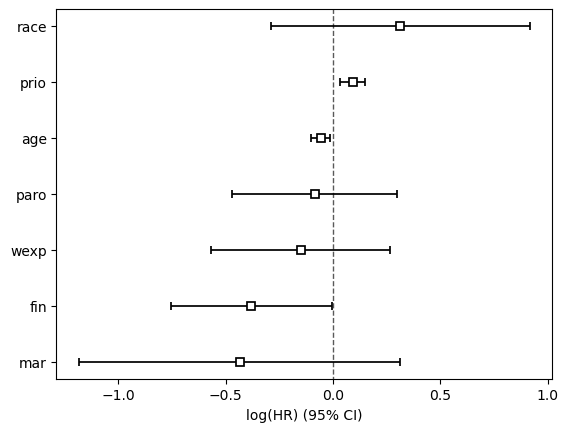

In [20]:
from lifelines.datasets import load_rossi
from lifelines import CoxPHFitter

rossi = load_rossi()
cph = CoxPHFitter()
cph.fit(rossi, duration_col='week', event_col='arrest')

cph.plot()

<Axes: >

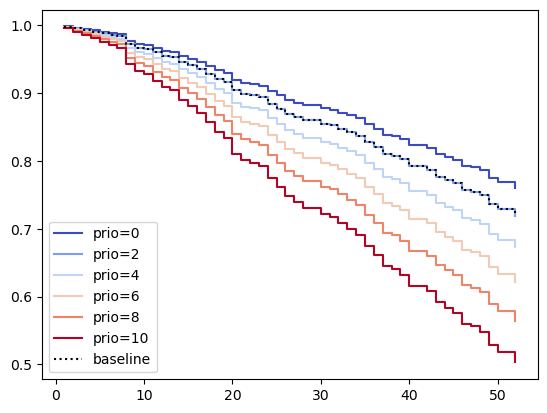

In [21]:
from lifelines.datasets import load_rossi
from lifelines import CoxPHFitter

rossi = load_rossi()
cph = CoxPHFitter()
cph.fit(rossi, duration_col='week', event_col='arrest')

cph.plot_partial_effects_on_outcome(covariates='prio', values=[0, 2, 4, 6, 8, 10], cmap='coolwarm')

<Axes: >

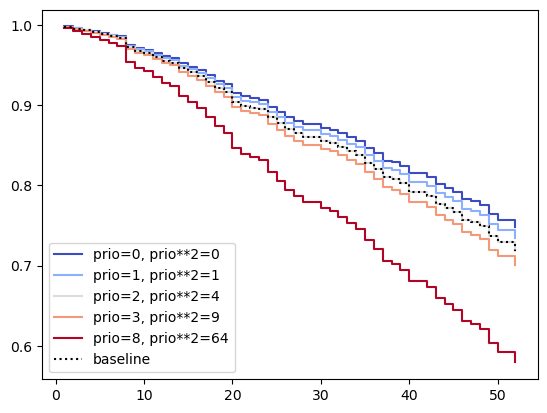

In [22]:
rossi['prio**2'] = rossi['prio'] ** 2

cph.fit(rossi, 'week', 'arrest')

cph.plot_partial_effects_on_outcome(
    covariates=['prio', 'prio**2'],
    values=[
        [0, 0],
        [1, 1],
        [2, 4],
        [3, 9],
        [8, 64],
    ],
    cmap='coolwarm')

<Axes: >

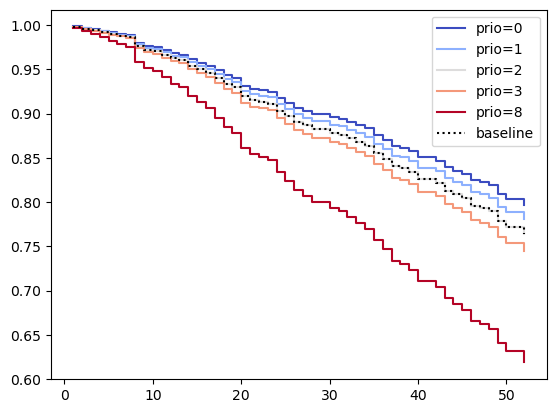

In [23]:
cph.fit(rossi, 'week', 'arrest', formula="prio + I(prio**2)")

cph.plot_partial_effects_on_outcome(
    covariates=['prio'],
    values=[0, 1, 2, 3, 8],
    cmap='coolwarm')

In [25]:
# cph.plot_partial_effects_on_outcome(
#     covariates=["a_categorical_variable"]
#     values=["A", "B", ...],
#     plot_baseline=False)

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
                   strata = wexp
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -580.89
         time fit was run = 2025-10-15 19:50:37 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.38      0.68      0.19           -0.76           -0.01                0.47                0.99
age       -0.06      0.94      0.02           -0.10           -0.01                0.90                0.99
race       0.31      1.36      0.31           -0.30            0.91                0.74                2.49
mar       -0.45      0.64      0.38           -1.20            0.29                0.30                1.34
paro      -0.08      0.92      0.20           -0.47            0.30                0.63                1.35
prio       0.09      1.09      0.03            0.03            0.15                1.04                1.16

           cmp to     z      p  -log2(p)
covariate                               
fin          0.00 -1.99   0.05      4.42
age          0.00 -2.64   0.01      6.91
race         0.00  1.00   0.32      1.65
mar          0.00 -1.19   0.23      2.09
paro         0.00 -0.42   0.67      0.57
prio         0.00  3.16 <0.005      9.33
---
Concordance = 0.61
Partial AIC = 1173.77
log-likelihood ratio test = 23.77 on 6 df
-log2(p) of ll-ratio test = 10.77

<Axes: >

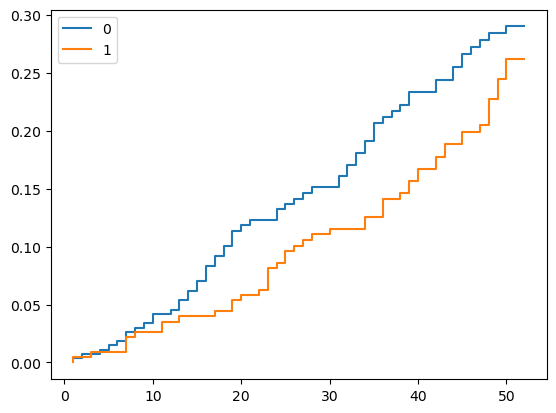

In [26]:
from lifelines.datasets import load_rossi
from lifelines import CoxPHFitter
rossi = load_rossi()

cph = CoxPHFitter()
cph.fit(rossi, 'week', event_col='arrest', strata=['wexp'])
cph.print_summary()


cph.baseline_survival_.shape
# (49, 2)
cph.baseline_cumulative_hazard_.plot(drawstyle="steps")

In [27]:
import pandas as pd
from lifelines import CoxPHFitter

df = pd.DataFrame({
    'T': [5, 3, 9, 8, 7, 4, 4, 3, 2, 5, 6, 7],
    'E': [1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0],
    'weights': [1.1, 0.5, 2.0, 1.6, 1.2, 4.3, 1.4, 4.5, 3.0, 3.2, 0.4, 6.2],
    'month': [10, 3, 9, 8, 7, 4, 4, 3, 2, 5, 6, 7],
    'age': [4, 3, 9, 8, 7, 4, 4, 3, 2, 5, 6, 7],
})

cph = CoxPHFitter()
cph.fit(df, 'T', 'E', weights_col='weights', robust=True)
cph.print_summary()

c:\Users\douglas.sgrott_indic\miniconda3\envs\tsfresh_venv\lib\site-packages\lifelines\utils\__init__.py:1163: ConvergenceWarning: Column age has high sample correlation with the duration column. This may harm convergence. This could be a form of 'complete separation'.     See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression

  warnings.warn(dedent(warning_text), ConvergenceWarning)
c:\Users\douglas.sgrott_indic\miniconda3\envs\tsfresh_venv\lib\site-packages\lifelines\fitters\coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 1.890. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

  warnings.warn(


<lifelines.CoxPHFitter: fitted with 29.4 total observations, 12.1 right-censored observations>
             duration col = 'T'
                event col = 'E'
              weights col = 'weights'
          robust variance = True
      baseline estimation = breslow
   number of observations = 29.4
number of events observed = 17.3
   partial log-likelihood = -20.54
         time fit was run = 2025-10-15 19:50:37 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
month      -3.15      0.04      0.14           -3.42           -2.89                0.03                0.06
age       -15.77      0.00      0.49          -16.73          -14.81                0.00                0.00

           cmp to      z      p  -log2(p)
covariate                                
month        0.00 -22.98 <0.005    385.78
age          0.00 -32.12 <0.005    749.50
---
Concordance = 0.97
Partial AIC = 45.08
log-likelihood ratio test = 46.45 on 2 df
-log2(p) of ll-ratio test = 33.50

In [28]:
from lifelines import CoxPHFitter

df = pd.DataFrame({
    'T': [5, 3, 9, 8, 7, 4, 4, 3, 2, 5, 6, 7],
    'E': [1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0],
    'month': [10, 3, 9, 8, 7, 4, 4, 3, 2, 5, 6, 7],
    'age': [4, 3, 9, 8, 7, 4, 4, 3, 2, 5, 6, 7],
    'id': [1, 1, 1, 1, 2, 3, 3, 4, 4, 5, 6, 7]
})

cph = CoxPHFitter()
cph.fit(df, 'T', 'E', cluster_col='id')
cph.print_summary()

c:\Users\douglas.sgrott_indic\miniconda3\envs\tsfresh_venv\lib\site-packages\lifelines\utils\__init__.py:1163: ConvergenceWarning: Column age has high sample correlation with the duration column. This may harm convergence. This could be a form of 'complete separation'.     See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression

  warnings.warn(dedent(warning_text), ConvergenceWarning)
c:\Users\douglas.sgrott_indic\miniconda3\envs\tsfresh_venv\lib\site-packages\lifelines\fitters\coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 1.890. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

  warnings.warn(


<lifelines.CoxPHFitter: fitted with 12 total observations, 3 right-censored observations>
             duration col = 'T'
                event col = 'E'
              cluster col = 'id'
          robust variance = True
      baseline estimation = breslow
   number of observations = 12
number of events observed = 9
   partial log-likelihood = -2.77
         time fit was run = 2025-10-15 19:50:37 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
month      -3.02      0.05      0.09           -3.20           -2.84                0.04                0.06
age       -15.11      0.00      0.56          -16.22          -14.01                0.00                0.00

           cmp to      z      p  -log2(p)
covariate                                
month        0.00 -33.04 <0.005    792.93
age          0.00 -26.90 <0.005    527.02
---
Concordance = 0.97
Partial AIC = 9.55
log-likelihood ratio test = 23.47 on 2 df
-log2(p) of ll-ratio test = 16.93

In [29]:
from lifelines.datasets import load_rossi
from lifelines import CoxPHFitter

rossi = load_rossi()

cph_spline = CoxPHFitter(baseline_estimation_method="spline", n_baseline_knots=5)
cph_spline.fit(rossi, 'week', event_col='arrest')

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>

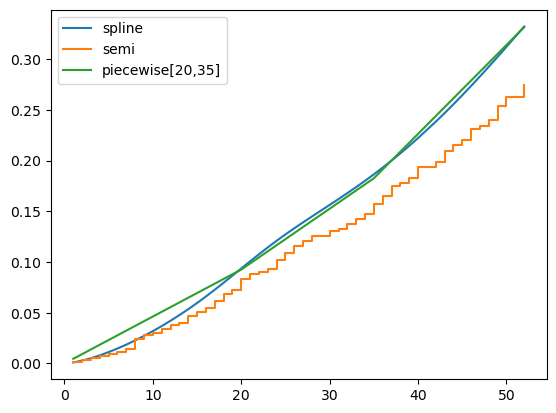

In [32]:
cph_semi = CoxPHFitter().fit(rossi, 'week', event_col='arrest')
cph_piecewise = CoxPHFitter(baseline_estimation_method="piecewise", breakpoints=[20, 35]).fit(rossi, 'week', event_col='arrest')

bch_key = "baseline cumulative hazard"

ax = cph_spline.baseline_cumulative_hazard_[bch_key].plot(label="spline")
cph_semi.baseline_cumulative_hazard_[bch_key].plot(ax=ax, drawstyle="steps-post", label="semi")
cph_piecewise.baseline_cumulative_hazard_[bch_key].plot(ax=ax, label="piecewise[20,35]")
plt.legend()

In [33]:
from lifelines import WeibullAFTFitter
from lifelines.datasets import load_rossi

rossi = load_rossi()

aft = WeibullAFTFitter()
aft.fit(rossi, duration_col='week', event_col='arrest')

aft.print_summary(3)  # access the results using aft.summary

<lifelines.WeibullAFTFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
   number of observations = 432
number of events observed = 114
           log-likelihood = -679.917
         time fit was run = 2025-10-15 19:50:57 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                   
lambda_ age        0.041     1.042     0.016           0.009           0.072               1.009               1.075
        fin        0.272     1.313     0.138           0.002           0.543               1.002               1.720
        mar        0.311     1.365     0.273          -0.224           0.847               0.799               2.332
        paro       0.059     1.061     0.140          -0.215           0.333               0.807               1.394
        prio      -0.066     0.936     0.021          -0.107          -0.025               0.899               0.976
        race      -0.225     0.799     0.220          -0.656           0.207               0.519               1.230
        wexp       0.107     1.112     0.152          -0.190           0.404               0.827               1.497
        Intercept  3.990    54.062     0.419           3.169           4.812              23.777             122.921
rho_    Intercept  0.339     1.404     0.089           0.165           0.514               1.179               1.671

                   cmp to      z       p  -log2(p)
param   covariate                                 
lambda_ age         0.000  2.544   0.011     6.512
        fin         0.000  1.973   0.049     4.365
        mar         0.000  1.139   0.255     1.973
        paro        0.000  0.421   0.674     0.570
        prio        0.000 -3.143   0.002     9.224
        race        0.000 -1.021   0.307     1.703
        wexp        0.000  0.703   0.482     1.053
        Intercept   0.000  9.521 <0.0005    68.978
rho_    Intercept   0.000  3.809 <0.0005    12.807
---
Concordance = 0.640
AIC = 1377.833
log-likelihood ratio test = 33.416 on 7 df
-log2(p) of ll-ratio test = 15.462

In [34]:
print(aft.median_survival_time_)
print(aft.mean_survival_time_)

87.74103133261258
103.78671283934625


In [36]:
aft = WeibullAFTFitter()

aft.fit(rossi, duration_col='week', event_col='arrest', ancillary=False)
# identical to aft.fit(rossi, duration_col='week', event_col='arrest', ancillary=None)


# aft.fit(rossi, duration_col='week', event_col='arrest', ancillary=some_df)


aft.fit(rossi, duration_col='week', event_col='arrest', ancillary=True)
# identical to aft.fit(rossi, duration_col='week', event_col='arrest', ancillary=rossi)
# identical to aft.fit(rossi, duration_col='week', event_col='arrest', ancillary="fin + age + race + wexp + mar + paro + prio")

aft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
   number of observations = 432
number of events observed = 114
           log-likelihood = -669.40
         time fit was run = 2025-10-15 19:51:08 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ age        0.10      1.10      0.03            0.04            0.16                1.04                1.17
        fin        0.24      1.28      0.15           -0.06            0.55                0.95                1.73
        mar        0.26      1.30      0.30           -0.33            0.85                0.72                2.35
        paro       0.09      1.10      0.15           -0.21            0.39                0.81                1.48
        prio      -0.08      0.92      0.02           -0.12           -0.04                0.89                0.96
        race       0.07      1.07      0.19           -0.30            0.44                0.74                1.55
        wexp      -0.34      0.71      0.15           -0.64           -0.04                0.53                0.96
        Intercept  2.68     14.65      0.60            1.51            3.85                4.55               47.22
rho_    age       -0.05      0.95      0.02           -0.08           -0.02                0.93                0.98
        fin       -0.01      0.99      0.15           -0.31            0.29                0.73                1.33
        mar        0.10      1.10      0.27           -0.44            0.63                0.65                1.87
        paro       0.02      1.02      0.16           -0.29            0.33                0.75                1.39
        prio       0.03      1.03      0.02           -0.01            0.08                0.99                1.08
        race      -0.46      0.63      0.25           -0.95            0.04                0.39                1.04
        wexp       0.56      1.74      0.17            0.23            0.88                1.26                2.42
        Intercept  1.48      4.41      0.41            0.68            2.29                1.97                9.89

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ age          0.00  3.43 <0.005     10.69
        fin          0.00  1.60   0.11      3.18
        mar          0.00  0.86   0.39      1.35
        paro         0.00  0.61   0.54      0.88
        prio         0.00 -4.24 <0.005     15.46
        race         0.00  0.36   0.72      0.48
        wexp         0.00 -2.22   0.03      5.26
        Intercept    0.00  4.50 <0.005     17.14
rho_    age          0.00 -3.10 <0.005      9.01
        fin          0.00 -0.09   0.92      0.11
        mar          0.00  0.36   0.72      0.47
        paro         0.00  0.12   0.90      0.15
        prio         0.00  1.44   0.15      2.73
        race         0.00 -1.79   0.07      3.77
        wexp         0.00  3.32 <0.005     10.13
        Intercept    0.00  3.60 <0.005     11.62
---
Concordance = 0.63
AIC = 1370.80
log-likelihood ratio test = 54.45 on 14 df
-log2(p) of ll-ratio test = 19.83

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

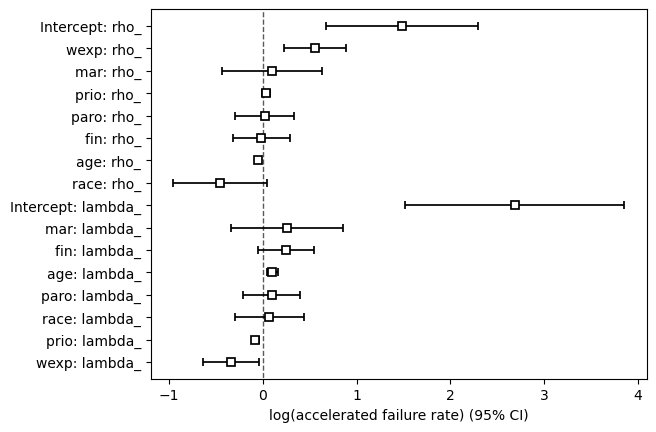

In [37]:
from matplotlib import pyplot as plt

wft = WeibullAFTFitter().fit(rossi, 'week', 'arrest', ancillary=True)
wft.plot()

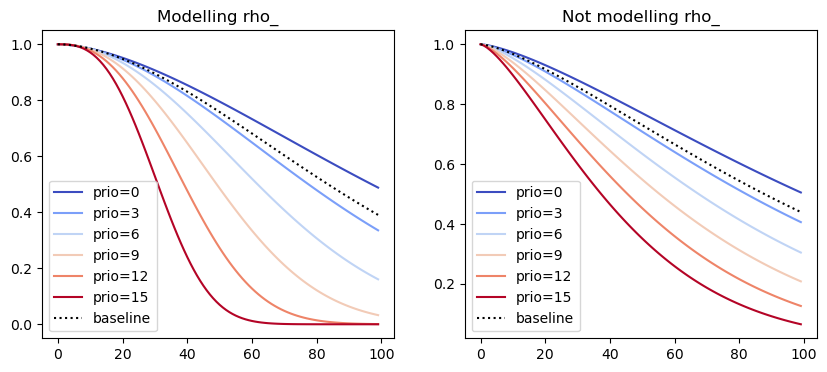

In [38]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

times = np.arange(0, 100)
wft_model_rho = WeibullAFTFitter().fit(rossi, 'week', 'arrest', ancillary=True, timeline=times)
wft_model_rho.plot_partial_effects_on_outcome('prio', range(0, 16, 3), cmap='coolwarm', ax=ax[0])
ax[0].set_title("Modelling rho_")

wft_not_model_rho = WeibullAFTFitter().fit(rossi, 'week', 'arrest', ancillary=False, timeline=times)
wft_not_model_rho.plot_partial_effects_on_outcome('prio', range(0, 16, 3), cmap='coolwarm', ax=ax[1])
ax[1].set_title("Not modelling rho_");

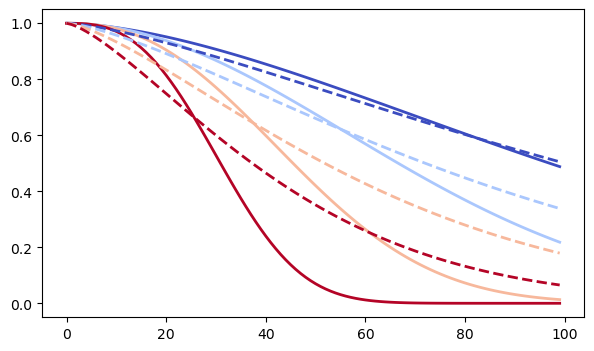

In [39]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 4))

# modeling rho == solid line
wft_model_rho.plot_partial_effects_on_outcome('prio', range(0, 16, 5), cmap='coolwarm', ax=ax, lw=2, plot_baseline=False)

# not modeling rho == dashed line
wft_not_model_rho.plot_partial_effects_on_outcome('prio', range(0, 16, 5), cmap='coolwarm', ax=ax, ls='--', lw=2, plot_baseline=False)

ax.get_legend().remove()

In [40]:
X = rossi.loc[:10]

aft.predict_cumulative_hazard(X, ancillary=X)
aft.predict_survival_function(X, ancillary=X)
aft.predict_median(X, ancillary=X)
aft.predict_percentile(X, p=0.9, ancillary=X)
aft.predict_expectation(X, ancillary=X)

0     210.371924
1      47.937821
2      23.926127
3     163.598112
4      53.345201
5      92.125023
6     170.699338
7      80.636068
8      80.201289
9      72.462424
10    238.862748
dtype: float64

In [41]:
aft_with_elastic_penalty = WeibullAFTFitter(penalizer=1e-4, l1_ratio=1.0)
aft_with_elastic_penalty.fit(rossi, 'week', 'arrest')
aft_with_elastic_penalty.predict_median(rossi)

aft_with_elastic_penalty.print_summary(columns=['coef', 'exp(coef)'])

<lifelines.WeibullAFTFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
                penalizer = 0.0001
   number of observations = 432
number of events observed = 114
           log-likelihood = -679.97
         time fit was run = 2025-10-15 19:51:12 UTC

---
                   coef exp(coef)
param   covariate                
lambda_ age        0.04      1.04
        fin        0.27      1.31
        mar        0.31      1.36
        paro       0.06      1.06
        prio      -0.07      0.94
        race      -0.22      0.80
        wexp       0.11      1.11
        Intercept  3.99     54.11
rho_    Intercept  0.34      1.40
---
Concordance = 0.64
AIC = 1377.93
log-likelihood ratio test = 33.31 on 7 df
-log2(p) of ll-ratio test = 15.40

In [42]:
from lifelines import LogLogisticAFTFitter
from lifelines import LogNormalAFTFitter

llf = LogLogisticAFTFitter().fit(rossi, 'week', 'arrest')
lnf = LogNormalAFTFitter().fit(rossi, 'week', 'arrest')

In [43]:
from lifelines import GeneralizedGammaRegressionFitter
from lifelines.datasets import load_rossi

df = load_rossi()
df['Intercept'] = 1.

# this will regress df against all 3 parameters
ggf = GeneralizedGammaRegressionFitter(penalizer=1.).fit(df, 'week', 'arrest')
ggf.print_summary()

# If we want fine control over the parameters <-> covariates.
# The values in the dict become can be formulas, or column names in lists:
regressors = {
    'mu_': rossi.columns.difference(['arrest', 'week']),
    'sigma_': ["age", "Intercept"],
    'lambda_': 'age + 1',
}

ggf = GeneralizedGammaRegressionFitter(penalizer=0.0001).fit(df, 'week', 'arrest', regressors=regressors)
ggf.print_summary()

<lifelines.GeneralizedGammaRegressionFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
                penalizer = 1.0
   number of observations = 432
number of events observed = 114
           log-likelihood = -686.63
         time fit was run = 2025-10-15 19:51:13 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
sigma_  fin       -0.05      0.95      0.09           -0.23            0.12                0.79                1.13
        age       -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
        race       0.10      1.10      0.14           -0.17            0.37                0.84                1.45
        wexp      -0.09      0.91      0.09           -0.27            0.09                0.76                1.09
        mar       -0.11      0.89      0.14           -0.38            0.16                0.68                1.18
        paro      -0.01      0.99      0.09           -0.19            0.17                0.83                1.19
        prio       0.01      1.01      0.02           -0.02            0.04                0.98                1.04
        Intercept -0.66      0.52      1.07           -2.75            1.44                0.06                4.20
mu_     fin        0.07      1.07      0.08           -0.09            0.23                0.92                1.25
        age        0.01      1.01      0.01           -0.00            0.03                1.00                1.03
        race      -0.02      0.98      0.12           -0.26            0.22                0.77                1.24
        wexp       0.06      1.06      0.08           -0.11            0.22                0.90                1.24
        mar        0.07      1.07      0.12           -0.17            0.31                0.84                1.36
        paro       0.01      1.01      0.08           -0.15            0.18                0.86                1.19
        prio      -0.02      0.98      0.01           -0.05            0.01                0.95                1.01
        Intercept  4.43     83.89      0.23            3.97            4.89               52.96              132.90
lambda_ fin       -0.03      0.97      0.08           -0.19            0.13                0.83                1.13
        age       -0.00      1.00      0.01           -0.01            0.01                0.99                1.01
        race       0.06      1.07      0.13           -0.18            0.31                0.83                1.36
        wexp      -0.05      0.95      0.08           -0.21            0.11                0.81                1.12
        mar       -0.07      0.93      0.13           -0.32            0.18                0.73                1.20
        paro      -0.01      0.99      0.08           -0.17            0.16                0.84                1.17
        prio       0.00      1.00      0.01           -0.02            0.03                0.98                1.03
        Intercept  1.35      3.87      0.67            0.04            2.66                1.04               14.36

                   cmp to     z      p  -log2(p)
param   covariate                               
sigma_  fin          0.00 -0.60   0.55      0.87
        age          0.00 -0.12   0.91      0.14
        race         0.00  0.71   0.48      1.07
        wexp         0.00 -0.99   0.32      1.64
        mar          0.00 -0.80   0.43      1.23
        paro         0.00 -0.11   0.92      0.13
        prio         0.00  0.54   0.59      0.76
        Intercept    0.00 -0.62   0.54      0.89
mu_     fin          0.00  0.87   0.38      1.39
        age          0.00  1.76   0.08      3.67
        race        

<lifelines.GeneralizedGammaRegressionFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
                penalizer = 0.0001
   number of observations = 432
number of events observed = 114
           log-likelihood = -681.51
         time fit was run = 2025-10-15 19:51:15 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
mu_     age        0.23      1.25      0.26           -0.29            0.75                0.75                2.11
        fin        0.22      1.25      0.98           -1.70            2.15                0.18                8.57
        mar        0.08      1.09      0.27           -0.44            0.61                0.64                1.85
        paro       0.26      1.29      0.16           -0.06            0.57                0.94                1.77
        prio      -0.07      0.94      0.04           -0.14            0.01                0.87                1.01
        race      -0.16      0.85      0.23           -0.61            0.29                0.54                1.34
        wexp       0.02      1.02      0.14           -0.26            0.30                0.77                1.34
sigma_  age        0.08      1.09      0.01            0.06            0.11                1.06                1.11
        Intercept -1.74      0.17      0.09           -1.92           -1.57                0.15                0.21
lambda_ Intercept  1.02      2.77      0.22            0.58            1.45                1.79                4.28
        age       -0.03      0.97      0.12           -0.27            0.21                0.76                1.24

                   cmp to      z      p  -log2(p)
param   covariate                                
mu_     age          0.00   0.86   0.39      1.35
        fin          0.00   0.23   0.82      0.29
        mar          0.00   0.31   0.75      0.41
        paro         0.00   1.58   0.11      3.13
        prio         0.00  -1.73   0.08      3.59
        race         0.00  -0.69   0.49      1.03
        wexp         0.00   0.13   0.90      0.16
sigma_  age          0.00   6.83 <0.005     36.78
        Intercept    0.00 -19.97 <0.005    292.22
lambda_ Intercept    0.00   4.58 <0.005     17.69
        age          0.00  -0.23   0.81      0.30
---
AIC = 1385.02
log-likelihood ratio test = 30.13 on 8 df
-log2(p) of ll-ratio test = 12.28

In [44]:
from lifelines import LogLogisticAFTFitter, WeibullAFTFitter, LogNormalAFTFitter
from lifelines.datasets import load_rossi

rossi = load_rossi()

llf = LogLogisticAFTFitter().fit(rossi, 'week', 'arrest')
lnf = LogNormalAFTFitter().fit(rossi, 'week', 'arrest')
wf = WeibullAFTFitter().fit(rossi, 'week', 'arrest')

print(llf.AIC_)  # 1377.877
print(lnf.AIC_)  # 1384.469
print(wf.AIC_)   # 1377.833, slightly the best model.


# with some heterogeneity in the ancillary parameters
ancillary = rossi[['prio']]
llf = LogLogisticAFTFitter().fit(rossi, 'week', 'arrest', ancillary=ancillary)
lnf = LogNormalAFTFitter().fit(rossi, 'week', 'arrest', ancillary=ancillary)
wf = WeibullAFTFitter().fit(rossi, 'week', 'arrest', ancillary=ancillary)

print(llf.AIC_) # 1377.89, the best model here, but not the overall best.
print(lnf.AIC_) # 1380.79
print(wf.AIC_)  # 1379.21

1377.877012356247
1384.4692508817016
1377.8331278951669
1377.8977823020325
1380.7974417743328
1379.2121834700297


In [45]:
from lifelines.datasets import load_diabetes

df = load_diabetes()
df['gender'] = df['gender'] == 'male'

print(df.head())


wf = WeibullAFTFitter().fit_interval_censoring(df, lower_bound_col='left', upper_bound_col='right')
wf.print_summary()


   left  right  gender
1    24     27    True
2    22     22   False
3    37     39    True
4    20     20    True
5     1     16    True


<lifelines.WeibullAFTFitter: fitted with 731 total observations, 136 interval-censored observations>
          lower bound col = 'left'
          upper bound col = 'right'
                event col = 'E_lifelines_added'
   number of observations = 731
number of events observed = 595
           log-likelihood = -2027.20
         time fit was run = 2025-10-15 19:51:17 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ gender     0.05      1.05      0.03           -0.01            0.10                0.99                1.10
        Intercept  2.91     18.32      0.02            2.86            2.95               17.53               19.14
rho_    Intercept  1.04      2.83      0.03            0.98            1.09                2.67                2.99

                   cmp to      z      p  -log2(p)
param   covariate                                
lambda_ gender       0.00   1.66   0.10      3.38
        Intercept    0.00 130.15 <0.005       inf
rho_    Intercept    0.00  36.91 <0.005    988.46
---
AIC = 4060.39
log-likelihood ratio test = 2.74 on 1 df
-log2(p) of ll-ratio test = 3.35

In [46]:
from lifelines import AalenAdditiveFitter
from lifelines.datasets import load_dd

data = load_dd()
data.head()

,ctryname,cowcode2,politycode,un_region_name,un_continent_name,ehead,leaderspellreg,democracy,regime,start_year,duration,observed
0,Afghanistan,700,700.0,Southern Asia,Asia,Mohammad Zahir Shah,Mohammad Zahir Shah.Afghanistan.1946.1952.Mona...,Non-democracy,Monarchy,1946,7,1
1,Afghanistan,700,700.0,Southern Asia,Asia,Sardar Mohammad Daoud,Sardar Mohammad Daoud.Afghanistan.1953.1962.Ci...,Non-democracy,Civilian Dict,1953,10,1
2,Afghanistan,700,700.0,Southern Asia,Asia,Mohammad Zahir Shah,Mohammad Zahir Shah.Afghanistan.1963.1972.Mona...,Non-democracy,Monarchy,1963,10,1
3,Afghanistan,700,700.0,Southern Asia,Asia,Sardar Mohammad Daoud,Sardar Mohammad Daoud.Afghanistan.1973.1977.Ci...,Non-democracy,Civilian Dict,1973,5,0
4,Afghanistan,700,700.0,Southern Asia,Asia,Nur Mohammad Taraki,Nur Mohammad Taraki.Afghanistan.1978.1978.Civi...,Non-democracy,Civilian Dict,1978,1,0


In [47]:
aaf = AalenAdditiveFitter(coef_penalizer=1.0, fit_intercept=False)


In [48]:
data['T'] = data['duration']
data['E'] = data['observed']

In [49]:
aaf.fit(data, 'T', event_col='E', formula='un_continent_name + regime + start_year')


<lifelines.AalenAdditiveFitter: fitted with 1808 total observations, 340 right-censored observations>

In [50]:
aaf.cumulative_hazards_.head()


covariate,Intercept,un_continent_name[T.Americas],un_continent_name[T.Asia],un_continent_name[T.Europe],un_continent_name[T.Oceania],regime[T.Military Dict],regime[T.Mixed Dem],regime[T.Monarchy],regime[T.Parliamentary Dem],regime[T.Presidential Dem],start_year
1.0,-0.034474,-0.031727,0.062161,0.205764,-0.009559,0.076112,0.087288,-0.136155,0.048846,0.128475,9.247036e-05
2.0,0.142777,-0.024962,0.111224,0.208343,-0.079042,0.117041,0.362540,-0.229312,0.171033,0.123835,4.443162e-05
3.0,0.301534,-0.072123,0.109294,0.161443,0.063030,0.165533,0.686935,-0.273775,0.333004,0.149926,3.761394e-06
4.0,0.379690,0.068530,0.151615,0.260896,0.185569,0.226949,0.950164,-0.296112,0.373514,0.431099,-3.202543e-05
5.0,0.367494,0.202013,0.212519,0.242909,0.188740,0.251271,1.151324,-0.392617,0.549518,0.759273,-2.261094e-07


<Axes: >

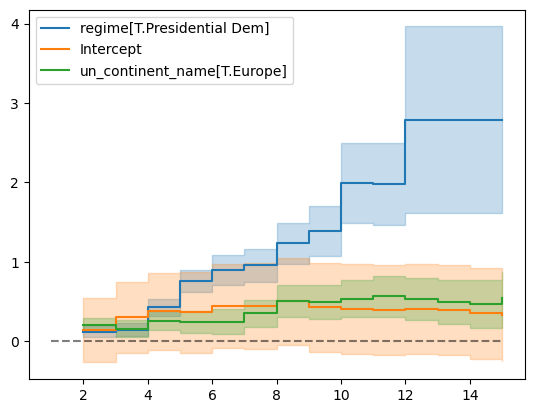

In [51]:
aaf.plot(columns=['regime[T.Presidential Dem]', 'Intercept', 'un_continent_name[T.Europe]'], iloc=slice(1,15))


In [52]:
ix = (data['ctryname'] == 'Canada') & (data['start_year'] == 2006)
harper = data.loc[ix]
print("Harper's unique data point:")
print(harper)

Harper's unique data point:
    ctryname  cowcode2  politycode    un_region_name un_continent_name  \
268   Canada        20        20.0  Northern America          Americas   

                     ehead                                     leaderspellreg  \
268  Stephen Joseph Harper  Stephen Joseph Harper.Canada.2006.2008.Parliam...   

     democracy             regime  start_year  duration  observed  T  E  
268  Democracy  Parliamentary Dem        2006         3         0  3  0  


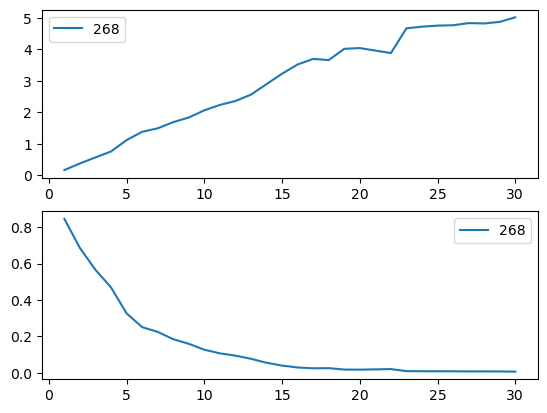

In [53]:
ax = plt.subplot(2,1,1)
aaf.predict_cumulative_hazard(harper).plot(ax=ax)

ax = plt.subplot(2,1,2)
aaf.predict_survival_function(harper).plot(ax=ax);

In [54]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

rossi = load_rossi().sample(frac=1.0, random_state=25)  # ensures the reproducibility of the example
train_rossi = rossi.iloc[:400]
test_rossi = rossi.iloc[400:]

cph_l1 = CoxPHFitter(penalizer=0.1, l1_ratio=1.).fit(train_rossi, 'week', 'arrest')
cph_l2 = CoxPHFitter(penalizer=0.1, l1_ratio=0.).fit(train_rossi, 'week', 'arrest')

print(cph_l1.score(test_rossi))
print(cph_l2.score(test_rossi))  # higher is better

-0.7360734993249076
-0.6823943087654121


In [55]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

rossi = load_rossi()

cph_l2 = CoxPHFitter(penalizer=0.1, l1_ratio=0.).fit(rossi, 'week', 'arrest')
cph_l1 = CoxPHFitter(penalizer=0.1, l1_ratio=1.).fit(rossi, 'week', 'arrest')

print(cph_l2.AIC_partial_) # lower is better
print(cph_l1.AIC_partial_)

1339.5661657040805
1364.761303079606


In [56]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

rossi = load_rossi()

cph = CoxPHFitter()
cph.fit(rossi, duration_col="week", event_col="arrest")

# fours ways to view the c-index:
# method one
cph.print_summary()

# method two
print(cph.concordance_index_)

# method three
print(cph.score(rossi, scoring_method="concordance_index"))

# method four
from lifelines.utils import concordance_index
print(concordance_index(rossi['week'], -cph.predict_partial_hazard(rossi), rossi['arrest']))

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -658.75
         time fit was run = 2025-10-15 19:51:19 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.38      0.68      0.19           -0.75           -0.00                0.47                1.00
age       -0.06      0.94      0.02           -0.10           -0.01                0.90                0.99
race       0.31      1.37      0.31           -0.29            0.92                0.75                2.50
wexp      -0.15      0.86      0.21           -0.57            0.27                0.57                1.30
mar       -0.43      0.65      0.38           -1.18            0.31                0.31                1.37
paro      -0.08      0.92      0.20           -0.47            0.30                0.63                1.35
prio       0.09      1.10      0.03            0.04            0.15                1.04                1.16

           cmp to     z      p  -log2(p)
covariate                               
fin          0.00 -1.98   0.05      4.40
age          0.00 -2.61   0.01      6.79
race         0.00  1.02   0.31      1.70
wexp         0.00 -0.71   0.48      1.06
mar          0.00 -1.14   0.26      1.97
paro         0.00 -0.43   0.66      0.59
prio         0.00  3.19 <0.005      9.48
---
Concordance = 0.64
Partial AIC = 1331.50
log-likelihood ratio test = 33.27 on 7 df
-log2(p) of ll-ratio test = 15.37

0.6403292470997135
0.6403292470997135
0.6403292470997135


In [57]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_regression_dataset
from lifelines.utils import k_fold_cross_validation

regression_dataset = load_regression_dataset()
cph = CoxPHFitter()
scores = k_fold_cross_validation(cph, regression_dataset, 'T', event_col='E', k=3)
print(scores)
#[-2.9896, -3.08810, -3.02747]

scores = k_fold_cross_validation(cph, regression_dataset, 'T', event_col='E', k=3, scoring_method="concordance_index")
print(scores)
# [0.5449, 0.5587, 0.6179]

[-3.0268604920906146, -3.2251531660640724, -3.0586941981153024]
[0.5048780487804878, 0.5904761904761905, 0.6060756972111554]


ICI =  0.003692605731447981
E50 =  0.0034421003529361283


(<Axes: title={'center': 'Smoothed calibration curve of \npredicted vs observed probabilities of t ≤ 25 mortality'}, xlabel='Predicted probability of \nt ≤ 25 mortality', ylabel='Observed probability of \nt ≤ 25 mortality'>,
 0.003692605731447981,
 0.0034421003529361283)

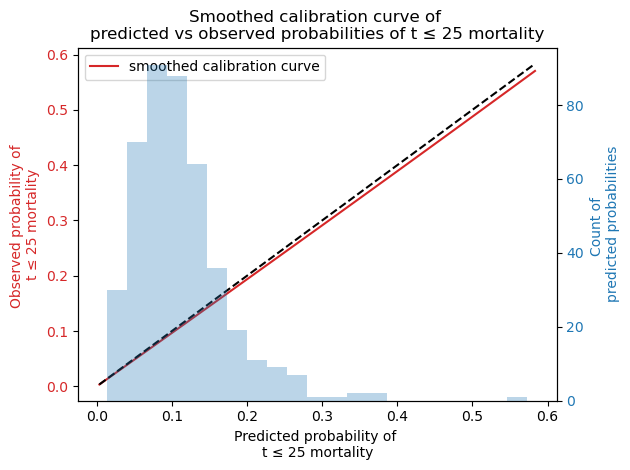

In [58]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi
from lifelines.calibration import survival_probability_calibration

regression_dataset = load_rossi()
cph = CoxPHFitter(baseline_estimation_method="spline", n_baseline_knots=3)
cph.fit(rossi, "week", "arrest")


survival_probability_calibration(cph, rossi, t0=25)

In [59]:
# all regression models can be used here, WeibullAFTFitter is used for illustration
wf = WeibullAFTFitter().fit(rossi, "week", "arrest")

# filter down to just censored subjects to predict remaining survival
censored_subjects = rossi.loc[~rossi['arrest'].astype(bool)]
censored_subjects_last_obs = censored_subjects['week']

# predict new survival function
wf.predict_survival_function(censored_subjects, conditional_after=censored_subjects_last_obs)

# predict median remaining life
wf.predict_median(censored_subjects, conditional_after=censored_subjects_last_obs)

3      138.430667
4       63.698595
5       62.596183
7       68.792648
8       35.571160
          ...    
427    156.634372
428     52.346448
429    120.150381
430     79.492663
431    100.942292
Length: 318, dtype: float64